In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data_frame=pd.read_csv("Iris.csv")

In [3]:
data_frame.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### __SepalLengthCm__: Canak yapraginn (sepal) uzunlugudur, santimetre cinsinden olculur.<br>__SepalWidthCm__: Canak yapraginn (sepal) genisligidir, santimetre cinsinden olculur.<br>__PetalLengthCm__: Tac yapraginn (Petal) uzunlugudur, santimetre cinsinden olculur.<br>__PetalWidthCm__: Canak yapraginn (petal) genisligidir, santimetre cinsinden olculur

In [4]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
data_frame["Species"].value_counts() #Dengeli bir dataset

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [6]:
data_frame = data_frame.drop("Id", axis=1) #Id gereksiz bir column ihtiyacimiz yok 

In [7]:
data_frame.describe() #dataset baya baya guzel ve dengeli denilebilir. Datalarda eksik gedik yok gibi

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


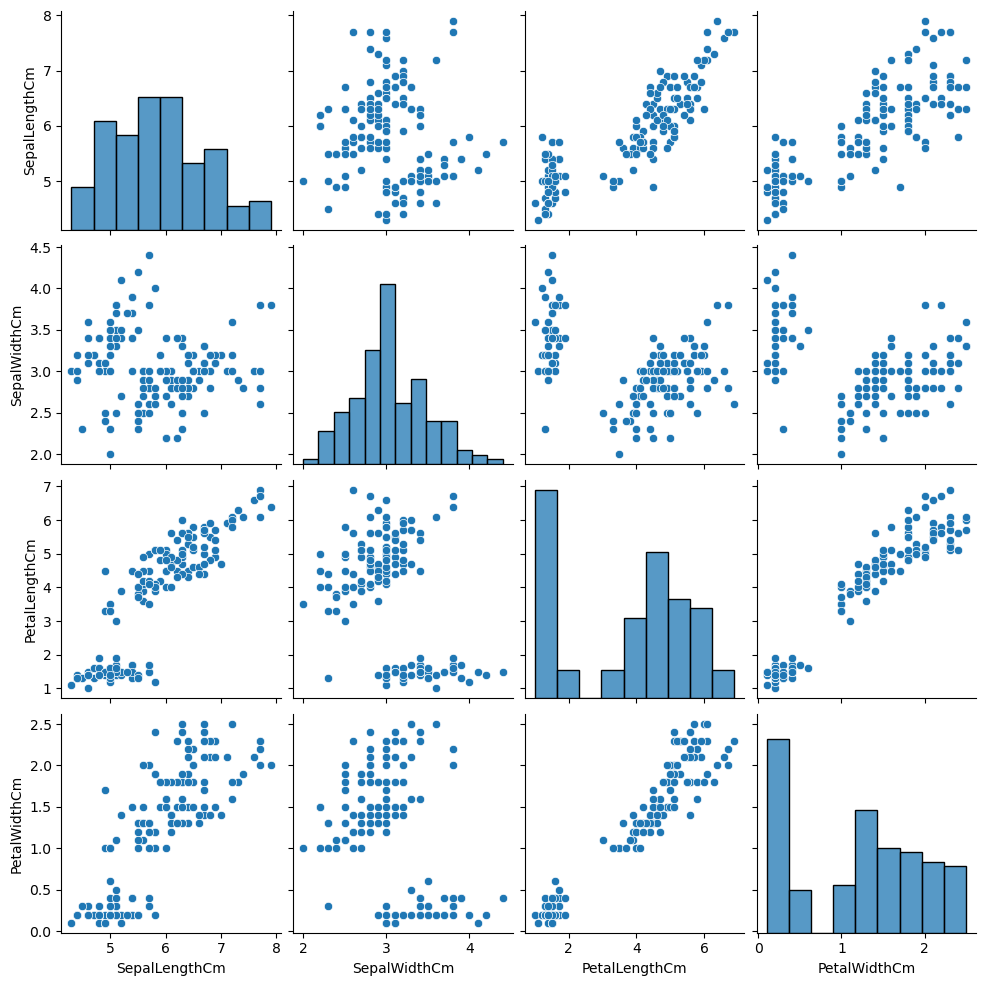

In [8]:
sns.pairplot(data_frame)
plt.show()

### Ozelliklerin Dagilimina filan bakabiliriz yukarida

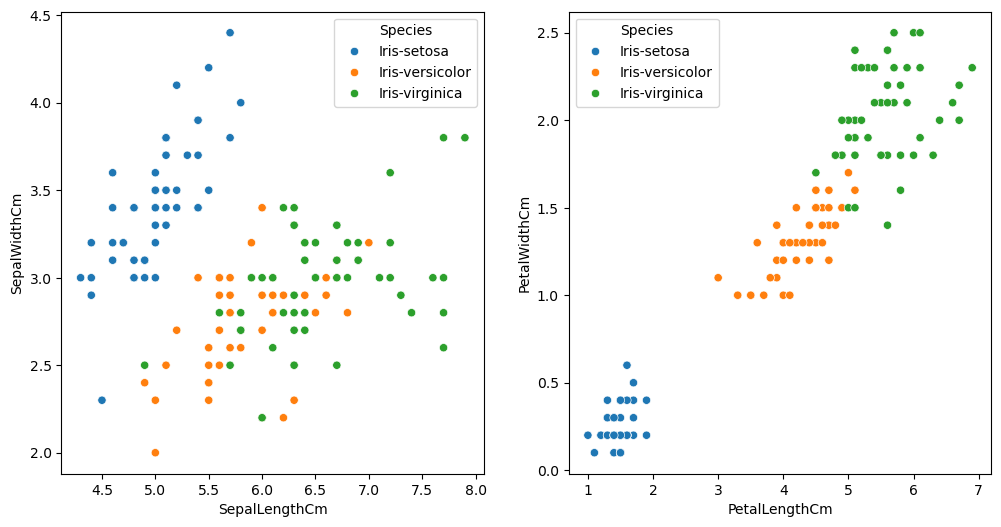

In [9]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.scatterplot(x=data_frame["SepalLengthCm"], y=data_frame["SepalWidthCm"], hue=data_frame["Species"])
plt.subplot(1,2,2)
sns.scatterplot(x=data_frame["PetalLengthCm"], y=data_frame["PetalWidthCm"], hue=data_frame["Species"])
plt.show()

### 2. grafikte direk elimizle bile %100 accuracy ile siniflandirma yapabiliriz.<br> ilk grafikte biraz daha zor olur ama min%97 filan olur yani

### Ozellikleri encode etmeden once X_train filan ayirmaliyiz ama y degeri icin encodeyi X-train filandan once yapabiliriz bir problem olmaz

In [10]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [11]:
data_frame["Species"] = label_encoder.fit_transform(data_frame["Species"])

In [12]:
data_frame["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [13]:
X = data_frame.drop("Species", axis=1)
y=data_frame["Species"]

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

### Naive Bayes algoritması için StandardScaler gibi ölçekleme (scaling) işlemlerine gerek yoktur.<br><br>Naive Bayes algoritması, verilerin dağılımını veya aralığını dikkate almaz. Onun tek derdi, __her bir özelliğin kategoriye ait olma olasılığıdır__<br><br>__Ölçekler Önemli Değil__: Naive Bayes, MaxTemp'in 30 derece mi yoksa 300 derece mi olduğuyla ilgilenmez. Sadece 30 derecenin belirli bir kategoriye (örneğin, "sıcak gün") ait olma olasılığını hesaplar.<br><br>__Mesafe Bağımsız__: LinearRegression veya SVR gibi algoritmalar, veri noktaları arasındaki mesafelere bakarak çalışır. Bu yüzden, MaxTemp'i 300'den 30'a ölçeklemek, mesafeleri etkilediği için bu modeller için kritiktir. Naive Bayes ise böyle bir hesaplama yapmaz.

### Ama Gaussian icin gerekli olabilir, fayda saglar. Tavsiye edilir. Fakat digerleri icin gerek yok

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [16]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.naive_bayes import GaussianNB #diyerek cagirma islemini yapabiliriz

In [18]:
gaus = GaussianNB()

In [19]:
gaus.fit(X_train_scaled, y_train)
y_pred = gaus.predict(X_test_scaled)

In [20]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [21]:
print("For Gaussian NB ; \n")
print("confusion matrix: \n", confusion_matrix(y_test, y_pred))
print("clasification report: ", classification_report(y_test, y_pred))
print("\naccuracy score: ", accuracy_score(y_test, y_pred))

For Gaussian NB ; 

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
clasification report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38


accuracy score:  1.0


### super bir sonuc verdi :)

[Sklearn/GaussianNB dökümantasyonuna gitmek icin tiklayabilirsiniz...](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)

# Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
logistic = LogisticRegression()
logistic.fit(X_train_scaled, y_train)
y_logistic_pred = logistic.predict(X_test_scaled)

In [24]:
print("for Logistic Reg; \n")
print("confusion matrix: \n", confusion_matrix(y_test, y_logistic_pred))
print("clasification report: ", classification_report(y_test, y_logistic_pred))
print("\naccuracy score: ", accuracy_score(y_test, y_logistic_pred))

for Logistic Reg; 

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
clasification report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38


accuracy score:  1.0


#### yani degisen bisi olmadi 

## HyperParameter Tuning

[Scikit-Learn/Logistic_Regression Dokumantasyonuna gitmek icin tiklayin](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [25]:
new_logistic = LogisticRegression()

parametreler = {
    "penalty" : ["l1", "l2"],
    "C" : [100, 10, 1, 0.1, 0.01],
    "solver" : ["newton-cg", "libliner", "lbfgs", "sag", "saga", "newton-cholesky"]

}

In [26]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(estimator=new_logistic, param_grid= parametreler, cv=5, scoring="accuracy")

In [27]:
import warnings
warnings.filterwarnings("ignore")

In [28]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1, 0.1, 0.01], 'penalty': ['l1', 'l2'],
                         'solver': ['newton-cg', 'libliner', 'lbfgs', 'sag',
                                    'saga', 'newton-cholesky']},
             scoring='accuracy')

In [29]:
print(grid.best_params_,"\n") #en iyi parametreler neymis

print(grid.best_score_, "\n") #en iyi accuracy skoru neymis

{'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'} 

0.9640316205533598 



In [30]:
y_new_log_pred = grid.predict(X_test_scaled)

print("for Logistic Reg hyperparameter tuning ; \n")
print("confusion matrix: \n", confusion_matrix(y_test, y_new_log_pred))
print("clasification report: ", classification_report(y_test, y_new_log_pred))
print("\naccuracy score: ", accuracy_score(y_test, y_new_log_pred))

for Logistic Reg hyperparameter tuning ; 

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
clasification report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38


accuracy score:  1.0


## Random Search CV

In [31]:
from sklearn.model_selection import RandomizedSearchCV

In [32]:
model_random= LogisticRegression()

random_cv = RandomizedSearchCV(estimator= model_random, param_distributions=parametreler, cv=5, n_iter=10, scoring="accuracy")
#n_iter-->denedigi random sayisi ,,,,, 

In [33]:
random_cv.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'C': [100, 10, 1, 0.1, 0.01],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['newton-cg', 'libliner',
                                                   'lbfgs', 'sag', 'saga',
                                                   'newton-cholesky']},
                   scoring='accuracy')

In [34]:
print(random_cv.best_params_, "\n", "score: ", random_cv.best_score_)

{'solver': 'saga', 'penalty': 'l2', 'C': 0.01} 
 score:  0.8383399209486166


In [35]:
y_pred_rscv = random_cv.predict(X_test_scaled)
print("for LRandom Search CV; \n")
print("confusion matrix: \n", confusion_matrix(y_test, y_pred_rscv))
print("clasification report: ", classification_report(y_test, y_pred_rscv))
print("\naccuracy score: ", accuracy_score(y_test, y_pred_rscv))

for LRandom Search CV; 

confusion matrix: 
 [[12  0  0]
 [ 0  8  6]
 [ 0  0 12]]
clasification report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.57      0.73        14
           2       0.67      1.00      0.80        12

    accuracy                           0.84        38
   macro avg       0.89      0.86      0.84        38
weighted avg       0.89      0.84      0.84        38


accuracy score:  0.8421052631578947


# One vs Rest

In [36]:
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

In [37]:
onevsone_model=OneVsOneClassifier(LogisticRegression()) #diyerek icine bir estimator verebiliriz
onevsrest_model=OneVsRestClassifier(LogisticRegression())

In [38]:
onevsone_model.fit(X_train_scaled, y_train)
y_one_pred = onevsone_model.predict(X_test_scaled)

score_one=accuracy_score(y_one_pred, y_test)
print("for one vs one ;\n")
print("score: ",score_one,"\n")

print(classification_report(y_one_pred, y_test),"\n")

print("confussion matrix: \n", confusion_matrix(y_one_pred, y_test))

for one vs one ;

score:  1.0 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38
 

confussion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]


In [42]:
onevsrest_model.fit(X_train_scaled, y_train)
y_rest_pred = onevsrest_model.predict(X_test_scaled)

score_rest=accuracy_score(y_rest_pred, y_test)
print("for one vs rest ;\n")
print("score: ",score_rest,"\n")

print(classification_report(y_rest_pred, y_test),"\n")

print("confussion matrix: \n", confusion_matrix(y_rest_pred, y_test))

for one vs rest ;

score:  1.0 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38
 

confussion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
